# 02 · UK, 9 August 2019: correlated losses beat an N-1 reserve
*Companion to* **Biggest Power Grid Failures: Engineering Analysis of History's Most Severe Blackouts, Cascades, and Grid Failures** *by Ganesh Kumar Pandey.* See **Chapter 9**.

National Grid ESO held about 1,000 MW of frequency-containment reserve, sized to the single largest
loss. Within about a second of one lightning strike, several *independent* losses stacked up. The loss
sequence below follows the ESO technical report (ref. [19] in the book):

| t (s) | Loss | MW |
|---|---|---|
| 0.0 | Embedded generation (vector shift) | 150 |
| 0.1 | Hornsea 1 offshore wind | 737 |
| 0.6 | Little Barford steam turbine | 244 |
| 1.0 | Embedded generation (RoCoF protection) | 350 |
| ~58 | Little Barford gas turbine 1A | 210 |

LFDD (Low Frequency Demand Disconnection) acts at 48.8 Hz and removed about 931 MW of demand.

> **Model note.** This is a simplified teaching model. Parameters are chosen to be plausible and to reproduce the *shape* of the reported event, not to replicate any operator's measured data. For the authoritative record, read the official report cited in the book.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
from gridfail import plotstyle as ps
ps.apply()
FIG = os.path.abspath(os.path.join('..', 'figures'))

In [2]:
from gridfail.frequency import FreqSystem, GenLoss, ShedStage, simulate, print_log

def uk2019(extra_losses=True, reserve_mw=528, battery_mw=472, lfdd=True):
    losses = [GenLoss(0.0, 150, 0, 'embedded gen, vector shift'),
              GenLoss(0.1, 737, 0, 'Hornsea 1'),
              GenLoss(0.6, 244, 2000, 'Little Barford ST'),
              GenLoss(1.0, 350, 0, 'embedded gen, RoCoF')]
    if extra_losses:
        losses.append(GenLoss(58.0, 210, 1500, 'Little Barford GT1A'))
    s = FreqSystem(demand_mw=29000, ek_mws=210000,
                   reserve_mw=reserve_mw, reserve_tc=8,
                   fast_reserve_mw=battery_mw, fast_reserve_tc=0.8,   # batteries
                   load_damping=0.019, losses=losses,
                   shed_stages=[ShedStage(48.8, 931, 0.1, 'LFDD')] if lfdd else [])
    return simulate(s, t_end=120, dt=0.01)

base = uk2019()
print_log(base)

t=   0.00s  f=50.000 Hz  LOSS      150 MW  embedded gen, vector shift
t=   0.10s  f=49.998 Hz  LOSS      737 MW  Hornsea 1
t=   0.60s  f=49.946 Hz  LOSS      244 MW  Little Barford ST
t=   1.00s  f=49.895 Hz  LOSS      350 MW  embedded gen, RoCoF
t=  58.00s  f=49.114 Hz  LOSS      210 MW  Little Barford GT1A
t=  86.84s  f=48.800 Hz  SHED      931 MW  LFDD (48.8 Hz)


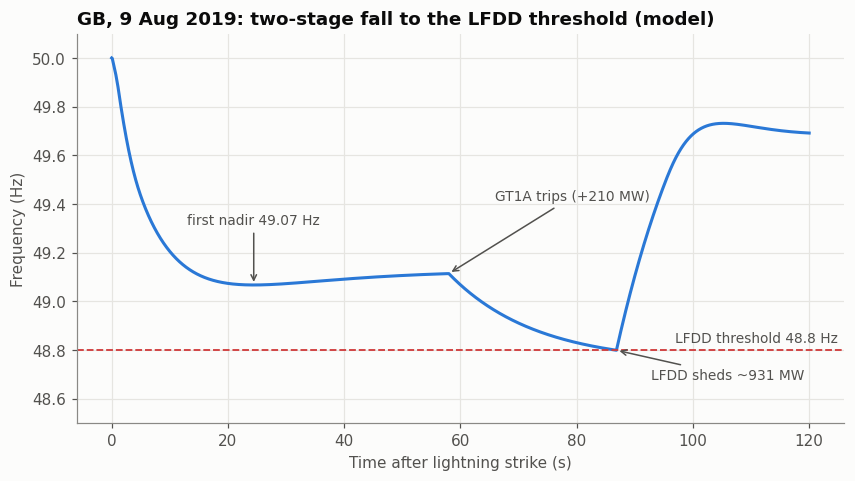

In [3]:
fig, ax = plt.subplots()
ax.plot(base['t'], base['f'], color=ps.SERIES[0], label='Simulated frequency')
ps.threshold(ax, 48.8, 'LFDD threshold 48.8 Hz')
for tk, fk, msg in base['log']:
    if 'GT1A' in msg:
        ax.annotate('GT1A trips (+210 MW)', xy=(tk, fk), xytext=(tk + 8, fk + 0.3), ha='left',
                    arrowprops=dict(arrowstyle='->', color=ps.TEXT2), color=ps.TEXT2, fontsize=9)
    if 'SHED' in msg:
        ax.annotate('LFDD sheds ~931 MW', xy=(tk, fk), xytext=(tk + 6, fk - 0.12),
                    arrowprops=dict(arrowstyle='->', color=ps.TEXT2), color=ps.TEXT2, fontsize=9)
i = np.argmin(base['f'][:5700])
ax.annotate(f'first nadir {base["f"][i]:.2f} Hz', xy=(base['t'][i], base['f'][i]),
            xytext=(base['t'][i], base['f'][i] + 0.25), ha='center',
            arrowprops=dict(arrowstyle='->', color=ps.TEXT2), color=ps.TEXT2, fontsize=9)
ax.set_xlabel('Time after lightning strike (s)'); ax.set_ylabel('Frequency (Hz)')
ax.set_title('GB, 9 Aug 2019: two-stage fall to the LFDD threshold (model)')
ax.set_ylim(48.5, 50.1)
fig.savefig(os.path.join(FIG, '02_uk2019_frequency.png'))
plt.show()

## What-if: which single change would have avoided LFDD?

Chapter 9 lists the root causes. Here we switch each one off in turn and check whether frequency still
reaches 48.8 Hz.

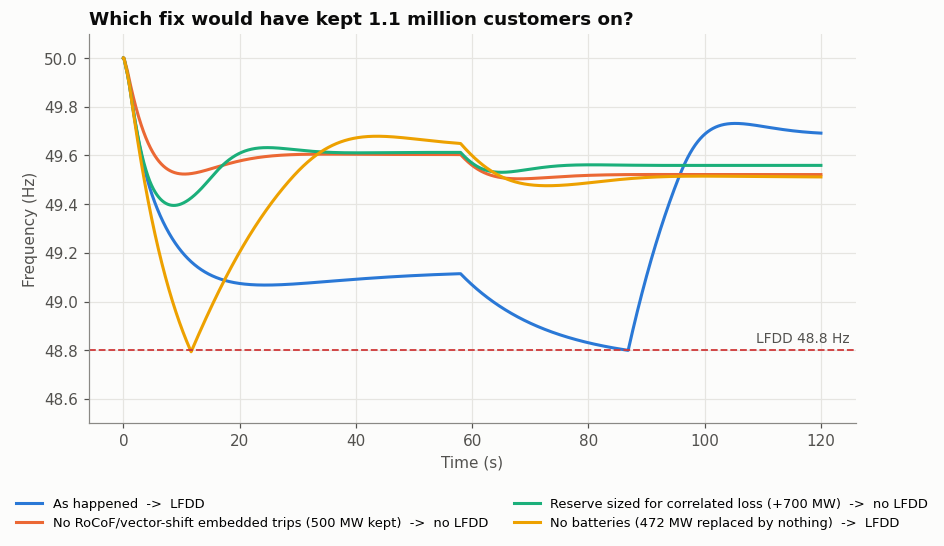

As happened                                             min f = 48.800 Hz   LFDD: True
No RoCoF/vector-shift embedded trips (500 MW kept)      min f = 49.504 Hz   LFDD: False
Reserve sized for correlated loss (+700 MW)             min f = 49.395 Hz   LFDD: False
No batteries (472 MW replaced by nothing)               min f = 48.794 Hz   LFDD: True


In [4]:
def did_shed(r):
    return any('SHED' in m for _, _, m in r['log'])

scenarios = {
    'As happened': uk2019(),
    'No RoCoF/vector-shift embedded trips (500 MW kept)':
        simulate(FreqSystem(
            demand_mw=29000, ek_mws=210000, reserve_mw=528, reserve_tc=8,
            fast_reserve_mw=472, fast_reserve_tc=0.8, load_damping=0.019,
            losses=[GenLoss(0.1, 737, 0, 'Hornsea 1'), GenLoss(0.6, 244, 2000, 'LB ST'),
                    GenLoss(58.0, 210, 1500, 'LB GT1A')],
            shed_stages=[ShedStage(48.8, 931, 0.1, 'LFDD')]), 120, 0.01),
    'Reserve sized for correlated loss (+700 MW)': uk2019(reserve_mw=1228),
    'No batteries (472 MW replaced by nothing)': uk2019(battery_mw=0),
}

fig, ax = plt.subplots()
for (lab, r), c in zip(scenarios.items(), ps.SERIES):
    ax.plot(r['t'], r['f'], color=c, label=f"{lab}  ->  {'LFDD' if did_shed(r) else 'no LFDD'}")
ps.threshold(ax, 48.8, 'LFDD 48.8 Hz')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Frequency (Hz)')
ax.set_title('Which fix would have kept 1.1 million customers on?')
ax.set_ylim(48.5, 50.1)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.16), ncol=2, fontsize=8.5)
fig.savefig(os.path.join(FIG, '02_uk2019_whatif.png'))
plt.show()

for lab, r in scenarios.items():
    print(f"{lab:55s} min f = {np.nanmin(r['f']):.3f} Hz   LFDD: {did_shed(r)}")

**Reading the result.** Keeping the 500 MW of embedded generation online, or holding reserve against a
*correlated* loss, both keep frequency above 48.8 Hz. Removing the batteries makes the first dip far
worse. This is the book's argument in numbers: N-1 reserve sizing and invisible embedded-generation
protection were the real failure, not the lightning.